In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('UCI_Adult_Income_Dataset.csv')
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
12690,35,Private,152734,Some-college,10,Married-civ-spouse,Protective-serv,Husband,Black,Male,0,0,40,?,<=50K
24128,45,Private,242391,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K
21327,27,Private,101618,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,<=50K
27318,40,Private,141583,10th,6,Never-married,Other-service,Unmarried,Black,Female,0,0,40,United-States,<=50K
29563,33,Private,272411,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,<=50K


In [17]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [5]:
# from this we can conclude that there are null values in only 3 columns --> workclass, occupation,native-country

In [6]:
df['workclass'].value_counts()  

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [14]:
df['workclass'].isnull().sum()

np.int64(2799)

In [15]:
(df['workclass'] == '?').sum()

np.int64(0)

In [16]:
df.replace('?', np.nan, inplace=True)

In [49]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [18]:
# Explore numerical columns
df[cat_cols].describe()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720


In [26]:
(df.isnull().sum()/len(df))*100

age               0.000000
workclass         5.730724
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
income            0.000000
dtype: float64

In [ ]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

## Filling Null Values

In [41]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='most_frequent')
df[['workclass','occupation','native-country']]=si.fit_transform(df[['workclass','occupation','native-country']])

In [35]:
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
4482,26,Private,159897,Some-college,10,Never-married,Exec-managerial,Unmarried,Black,Female,0,0,40,United-States,<=50K
6745,21,Private,182117,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,15,United-States,<=50K
35255,35,Private,166497,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1902,60,United-States,>50K.
31817,49,Private,402462,Bachelors,13,Married-spouse-absent,Transport-moving,Unmarried,White,Male,0,0,30,Columbia,<=50K
42098,26,Private,130018,HS-grad,9,Never-married,Craft-repair,Unmarried,White,Male,0,0,40,United-States,<=50K.


In [42]:
(df.isnull().sum()/len(df))*100

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
income            0.0
dtype: float64

## Removal of Duplicated Rows

In [46]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.drop_duplicates(inplace=True)

In [48]:
df.shape

(48813, 15)

## Analysis on Numerical Columns

In [50]:
df[num_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48813.000000,4.881300e+04,48813.000000,48813.000000,48813.000000,48813.000000
mean,38.647348,1.896679e+05,10.078688,1079.708705,87.554299,40.425051
std,13.709005,1.056062e+05,2.570257,7454.185982,403.118605,12.390954
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781400e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376200e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


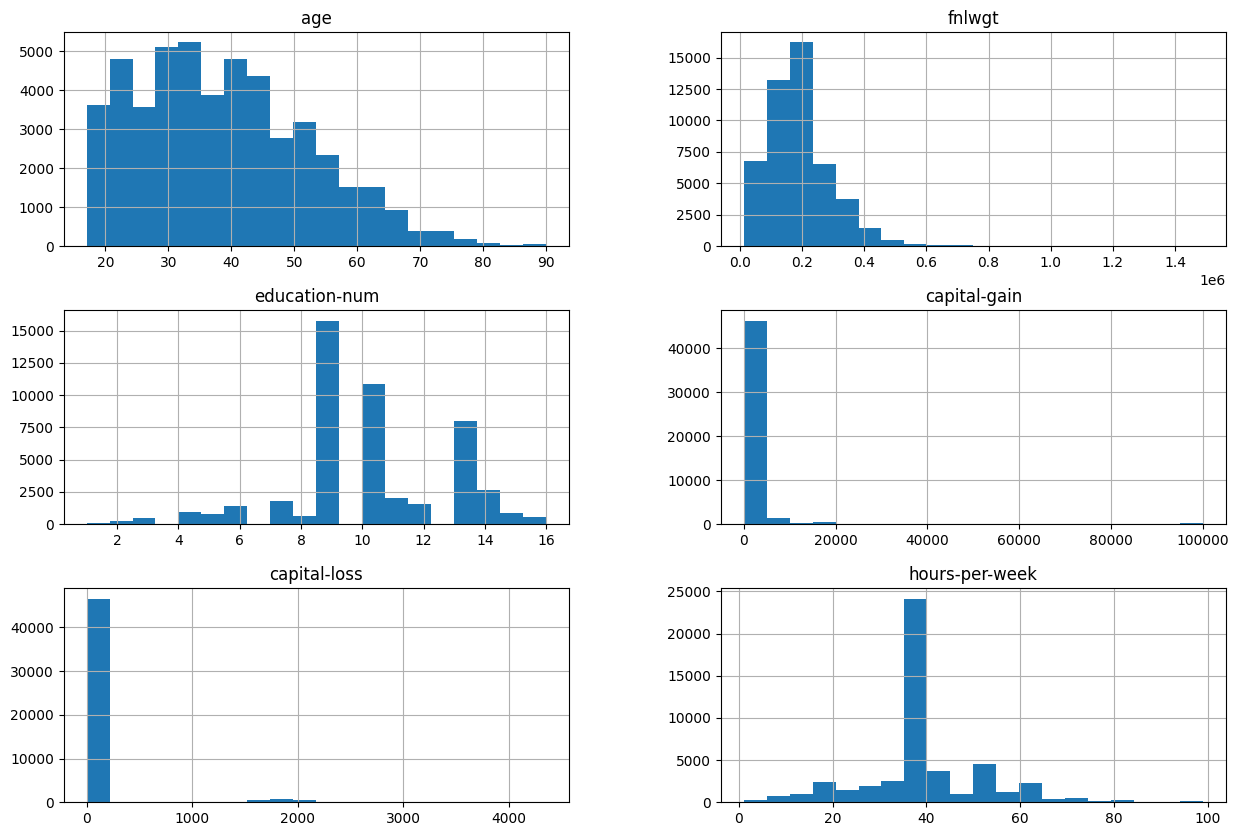

In [54]:
df[num_cols].hist(figsize=(15,10), bins=20)
plt.show()

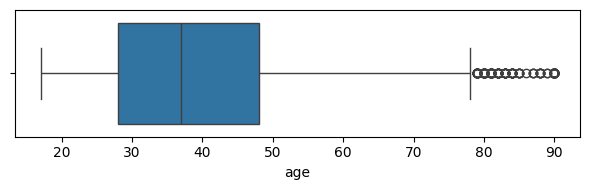

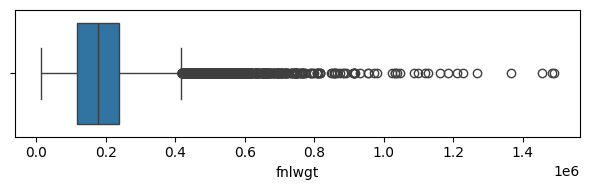

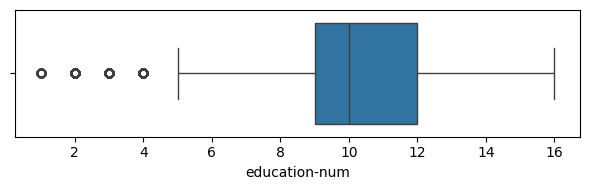

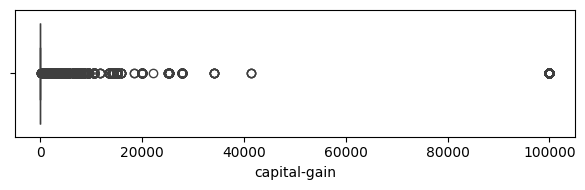

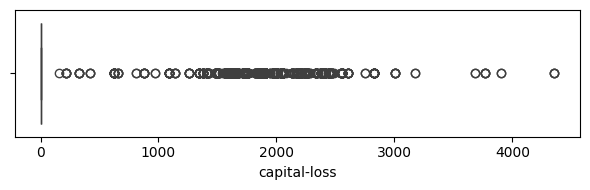

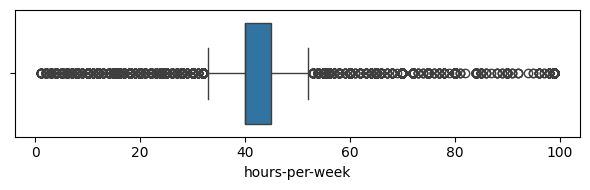

In [64]:
import seaborn as sns
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.tight_layout()
    plt.show()